In [57]:
import os
import numpy as np
import pickle
from statsmodels.stats.multitest import fdrcorrection
import scipy.stats as stats
import scipy.io as sio
import matplotlib.pyplot as plt
from nilearn.image import new_img_like
import pandas as pd
import nibabel as nib
import csv
from nilearn import plotting
# from rsatoolbox.inference import eval_fixed
# from rsatoolbox.model import ModelFixed
from glob import glob
import nilearn.image as nlimg
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight
from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr
from tqdm import tqdm
# from rsatoolbox.data.dataset import Dataset
# from rsatoolbox.rdm.calc import calc_rdm
# from rsatoolbox.rdm import RDMs

# Load neural data

In [3]:
allsub_avg = np.load("allsub_avg.npy", allow_pickle=True)

In [4]:
allsub_avg.shape

(20, 60, 153594)

In [12]:
# Read the CSV file
stim_file = pd.read_csv('../IAPS_fMRI_RSA/fmri_conditions_trial_ordered.csv')

# Filter rows where type is 'Nt', 'Pl', or 'Up'
filtered_stim = stim_file[stim_file['type'].isin(['Pl', 'Nt', 'Up'])]

# Define a custom order for 'type' (Pl, Nt, Up)
type_order = {'Pl': 1, 'Nt': 2, 'Up': 3}

# Create a new column 'type_order' based on the custom order
filtered_stim['type_order'] = filtered_stim['type'].map(type_order)

# Sort by 'type_order' first, then by 'stim_order'
sorted_stim = filtered_stim.sort_values(by=['type_order', 'stim_order'])

# Drop duplicates based on 'iaps_id' to retain unique values
unique_stim = sorted_stim.drop_duplicates(subset='iaps_id')

# Select the relevant columns ('stim_order', 'type', 'iaps_id') for the final output
final_output = unique_stim[['stim_order', 'type', 'iaps_id']]

# Reset the index
stim = final_output.reset_index(drop=True)

# Display the final output
print(stim)


    stim_order type  iaps_id
0            1   Pl     4680
1            2   Pl     4641
2            3   Pl     8250
3            4   Pl     8186
4            5   Pl     4626
5            6   Pl     2057
6            7   Pl     4624
7            8   Pl     4311
8            9   Pl     4597
9           10   Pl     4694
10          11   Pl     4610
11          12   Pl     2332
12          13   Pl     8030
13          14   Pl     2655
14          15   Pl     4658
15          16   Pl     2345
16          17   Pl     4599
17          18   Pl     4695
18          19   Pl     4693
19          20   Pl     4668
20           1   Nt     2305
21           2   Nt     2347
22           3   Nt     2398
23           4   Nt     5781
24           5   Nt     5600
25           6   Nt     2387
26           7   Nt     2374
27           8   Nt     2032
28           9   Nt     8034
29          10   Nt     2635
30          11   Nt     2102
31          12   Nt     2036
32          13   Nt     2411
33          14

# Create flag RDM

In [111]:
# Read the CSV file
flag_file = pd.read_csv('./flags.csv')
flag_file

,iaps_id,face_flag,social_flag
0,1114,N,N
1,1120,N,N
2,1205,N,N
3,1220,N,N
4,1271,N,N
5,1300,N,N
6,1302,N,N
7,1931,N,N
8,2032,Y,Y
9,2036,N,N


In [18]:
# Merge with the flag_file on 'iaps_id' to add the 'face_flag' column
stim_with_flags = stim.merge(flag_file[['iaps_id', 'face_flag']], on='iaps_id', how='left')

# Display the final output with the face_flag column
print(stim_with_flags)

    stim_order type  iaps_id face_flag
0            1   Pl     4680         Y
1            2   Pl     4641         Y
2            3   Pl     8250         N
3            4   Pl     8186         N
4            5   Pl     4626         Y
5            6   Pl     2057         Y
6            7   Pl     4624         Y
7            8   Pl     4311         N
8            9   Pl     4597         Y
9           10   Pl     4694         Y
10          11   Pl     4610         Y
11          12   Pl     2332         Y
12          13   Pl     8030         N
13          14   Pl     2655         N
14          15   Pl     4658         Y
15          16   Pl     2345         Y
16          17   Pl     4599         Y
17          18   Pl     4695         Y
18          19   Pl     4693         N
19          20   Pl     4668         Y
20           1   Nt     2305         Y
21           2   Nt     2347         Y
22           3   Nt     2398         N
23           4   Nt     5781         N
24           5   Nt     5

In [22]:
print('Face:', np.count_nonzero(stim_with_flags['face_flag']== 'Y'), 'Non-face:', np.count_nonzero(stim_with_flags['face_flag']== 'N'))



Face: 28 Non-face: 32


In [38]:
# Convert 'face_flag' to binary values for the RDM
face_binary = np.where(stim_with_flags['face_flag'] == 'Y', 1, 0)

# Create the face RDM based on binary values
n_stimuli = len(face_binary)
face_rdm = np.zeros((n_stimuli, n_stimuli))

for i in range(n_stimuli):
    for j in range(n_stimuli):
        face_rdm[i, j] = 0 if face_binary[i] == face_binary[j] else 1


In [72]:
# rdm_face = pd.DataFrame(face_rdm)
rdm_face = face_rdm

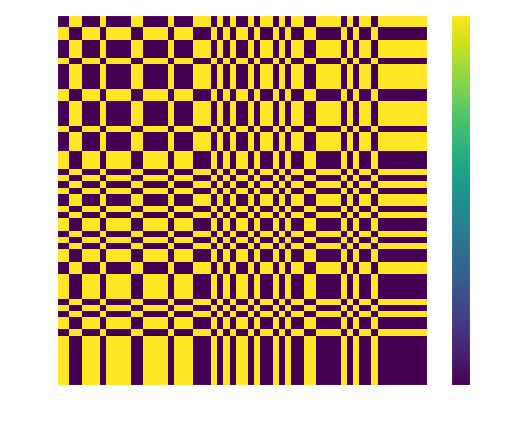

In [153]:

# make plot
fig, ax = plt.subplots(facecolor='white')
  
# show image
shw = ax.imshow(rdm_face)
  
# make bar
bar = plt.colorbar(shw)
  
# show plot with labels
plt.xlabel('IAPS Img')
plt.ylabel('IAPS Img')
# plt.xticks(ticks=np.arange(len(stim_with_flags['iaps_id'])), labels=stim_with_flags['iaps_id'])
# plt.yticks(ticks=np.arange(len(stim_with_flags['iaps_id'])), labels=stim_with_flags['iaps_id'])

bar.set_label('Pearson Correlation')
plt.show()

In [112]:
# Merge with the flag_file on 'iaps_id' to add the 'face_flag' column
stim_with_flags = stim.merge(flag_file[['iaps_id', 'social_flag']], on='iaps_id', how='left')

# Display the final output with the face_flag column
print(stim_with_flags)

    stim_order type  iaps_id social_flag
0            1   Pl     4680           N
1            2   Pl     4641           Y
2            3   Pl     8250           N
3            4   Pl     8186           N
4            5   Pl     4626           Y
5            6   Pl     2057           Y
6            7   Pl     4624           Y
7            8   Pl     4311           Y
8            9   Pl     4597           Y
9           10   Pl     4694           Y
10          11   Pl     4610           Y
11          12   Pl     2332           Y
12          13   Pl     8030           N
13          14   Pl     2655           Y
14          15   Pl     4658           Y
15          16   Pl     2345           Y
16          17   Pl     4599           Y
17          18   Pl     4695           Y
18          19   Pl     4693           N
19          20   Pl     4668           Y
20           1   Nt     2305           Y
21           2   Nt     2347           Y
22           3   Nt     2398           Y
23           4  

In [113]:
print('Social:', np.count_nonzero(stim_with_flags['social_flag']== 'Y'), 'Non-face:', np.count_nonzero(stim_with_flags['social_flag']== 'N'))


Social: 29 Non-face: 31


In [115]:
# Convert 'face_flag' to binary values for the RDM
social_binary = np.where(stim_with_flags['social_flag'] == 'Y', 1, 0)

# Create the face RDM based on binary values
n_stimuli = len(social_binary)
social_rdm = np.zeros((n_stimuli, n_stimuli))

for i in range(n_stimuli):
    for j in range(n_stimuli):
        social_rdm[i, j] = 0 if social_binary[i] == social_binary[j] else 1

rdm_social = social_rdm

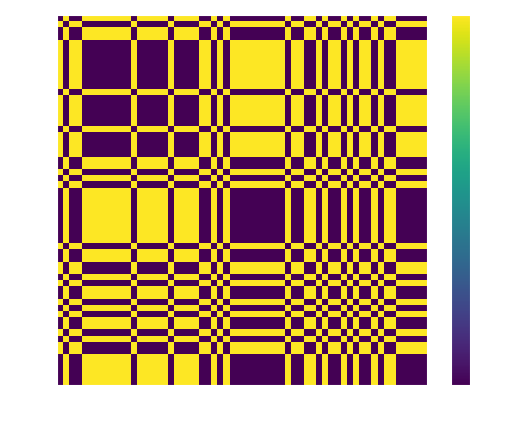

In [154]:

# make plot
fig, ax = plt.subplots(facecolor='white')
  
# show image
shw = ax.imshow(rdm_social)
  
# make bar
bar = plt.colorbar(shw)
  
# show plot with labels
plt.xlabel('IAPS Img')
plt.ylabel('IAPS Img')
# plt.xticks(ticks=np.arange(len(stim_with_flags['iaps_id'])), labels=stim_with_flags['iaps_id'])
# plt.yticks(ticks=np.arange(len(stim_with_flags['iaps_id'])), labels=stim_with_flags['iaps_id'])

bar.set_label('Pearson Correlation')
plt.show()

# Load Behavioral RDMs

In [43]:
rdm_behavioral = pd.read_csv("../IAPS_behavioral_RDM/rdm_behavioral_normed.csv", index_col=0)
rdm_behavioral = np.array(rdm_behavioral)


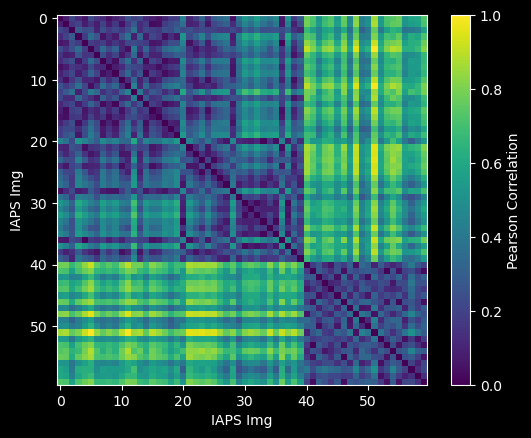

In [44]:
plt.style.use('dark_background')
# make plot
fig, ax = plt.subplots()
  
# show image
shw = ax.imshow(rdm_behavioral)
  
# make bar
bar = plt.colorbar(shw)
  
# show plot with labels
plt.xlabel('IAPS Img')
plt.ylabel('IAPS Img')
bar.set_label('Pearson Correlation')
plt.show()

# Searchlight analysis

In [48]:
# Import mask
mask = np.load("./mask.npy")
centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)

Finding searchlights...: 100%|██████████| 59159/59159 [00:29<00:00, 2016.33it/s]


Found 56949 searchlights


In [167]:

### 3. Searchlight Analysis Loop
# Now apply the searchlight analysis across all subjects and voxel centers
def cal_interaction(rdm_behavioral, rdm_face):
    n_subjects = allsub_avg.shape[0]
    eval_score_list = []

    # Flatten the behavioral and face RDMs
    rdm_behavioral_flat = upper_tri(rdm_behavioral)
    rdm_face_flat = upper_tri(rdm_face)

    X_interaction = rdm_behavioral * rdm_face
    
    
    return X_interaction

p = cal_interaction(rdm_behavioral, rdm_clip_text)

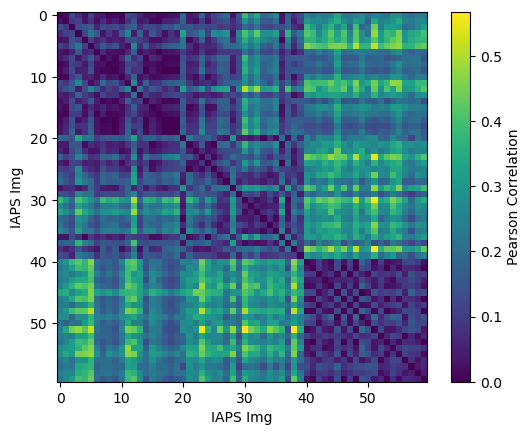

In [168]:
plt.style.use('default')
# make plot
fig, ax = plt.subplots()
  
# show image
shw = ax.imshow(p)
  
# make bar
bar = plt.colorbar(shw)
  
# show plot with labels
plt.xlabel('IAPS Img')
plt.ylabel('IAPS Img')
bar.set_label('Pearson Correlation')
plt.show()

In [75]:
def upper_tri(RDM):
    """upper_tri returns the upper triangular index of an RDM
dsad
    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]


### 2. Fit GLM Model to Neural RDM
# Behavioral RDM and Face RDM are provided, we will fit a model including both
def fit_glm_to_rdm(neural_rdm_flat, rdm_behavioral_flat, rdm_face_flat):
    # Use the flattened RDMs directly
    y = neural_rdm_flat  # Neural RDM is already flattened
    X_behavioral = rdm_behavioral_flat  # Behavioral RDM is already flattened
    X_face = rdm_face_flat  # Face RDM is already flattened
    
    # Interaction term (element-wise multiplication of RDMs)
    X_interaction = X_behavioral * X_face
    
    # Stack the predictors (Behavioral, Face, Interaction)
    X = np.vstack([X_behavioral, X_face, X_interaction]).T
    
    # Fit the GLM model using linear regression
    glm = LinearRegression().fit(X, y)
    
    # Return the regression coefficients (betas)
    return glm.coef_

### 3. Searchlight Analysis Loop
# Now apply the searchlight analysis across all subjects and voxel centers
def searchlight_analysis(allsub_avg, centers, neighbors, rdm_behavioral, rdm_face):
    n_subjects = allsub_avg.shape[0]
    eval_score_list = []

    # Flatten the behavioral and face RDMs
    rdm_behavioral_flat = upper_tri(rdm_behavioral)
    rdm_face_flat = upper_tri(rdm_face)
    
    for i in range(n_subjects):
        subj_data = allsub_avg[i]  # Get data for subject i
        
        # Generate searchlight RDMs for this subject
        subj_data_2d = np.nan_to_num(subj_data)

        image_value = np.arange(60)
        SL_RDMs = get_searchlight_RDMs(subj_data_2d, centers, neighbors, image_value, method='correlation')

        # The RDMs object contains several RDM matrices, let's extract them
        for idx, rdm in enumerate(SL_RDMs):
            # Extract the RDM corresponding to the voxel center at index 'idx'
            rdm_neural_flat = rdm.dissimilarities.flatten()  # Use the flattened dissimilarities
         
            # Fit GLM to the neural RDM at this center
            betas = fit_glm_to_rdm(rdm_neural_flat, rdm_behavioral_flat, rdm_face_flat)
            
            # Store the results (can be further processed or averaged over subjects)
            eval_score_list.append((centers[idx], betas))
    
    return eval_score_list

## GLM with face

In [76]:
eval_score_list = searchlight_analysis(allsub_avg, centers, neighbors, rdm_behavioral, rdm_face)


Calculating RDMs...: 100%|██████████| 100/100 [04:18<00:00,  2.59s/it]


### Export results

In [110]:
# Define the file path where you want to save the pickle file
file_path = './eval_score_list_face.pkl'

# Save eval_score_list to a pickle file
with open(file_path, 'wb') as file:
    pickle.dump(eval_score_list, file)


In [120]:
n_subjects = 20
n_voxel_centers = len(eval_score_list) // n_subjects

# Extract betas for each term and reshape
betas_behavioral = np.array([betas[0] for _, betas in eval_score_list]).reshape(n_subjects, n_voxel_centers)
betas_face = np.array([betas[1] for _, betas in eval_score_list]).reshape(n_subjects, n_voxel_centers)
betas_interaction = np.array([betas[2] for _, betas in eval_score_list]).reshape(n_subjects, n_voxel_centers)
# Perform t-tests across subjects for each term
t_values_behavioral, p_values_behavioral = stats.ttest_1samp(betas_behavioral, 0, axis=0)
t_values_face, p_values_face = stats.ttest_1samp(betas_face, 0, axis=0)
t_values_interaction, p_values_interaction = stats.ttest_1samp(betas_interaction, 0, axis=0)
# Apply FDR correction
_, p_values_behavioral_fdr = fdrcorrection(p_values_behavioral, alpha=0.05)
_, p_values_face_fdr = fdrcorrection(p_values_face, alpha=0.05)
_, p_values_interaction_fdr = fdrcorrection(p_values_interaction, alpha=0.05)
# Select significant voxel centers
significant_behavioral = p_values_behavioral_fdr < 0.05
significant_face = p_values_face_fdr < 0.05
significant_interaction = p_values_interaction_fdr < 0.05


In [106]:
# Dimensions of the voxel space
x, y, z = 53, 63, 46  # Adjust these dimensions to match your data

# Extract unique voxel indices from the first subject's data
n_subjects = 20
voxel_indices = np.array([center for center, _ in eval_score_list[:len(eval_score_list) // n_subjects]])

# Function to map t-values to voxel space and plot
def plot_t_values_in_brain(t_values, significant_mask, title, tmp_img):
    # Initialize an array for the t-statistics in 3D space
    t_stat_sig = np.full((x * y * z), np.nan)
    
    # Map significant t-values to their voxel indices
    significant_voxel_indices = voxel_indices[significant_mask]
    t_stat_sig[significant_voxel_indices] = t_values[significant_mask]
    
    # Reshape the 1D t-statistics array into a 3D array matching the voxel space
    t_stat_sig_3d = t_stat_sig.reshape([x, y, z])
    
    # Create a new image object from the 3D t-statistics
    t_stat_sig_img = new_img_like(tmp_img, t_stat_sig_3d)
    
    # View the image
    view = plotting.view_img(t_stat_sig_img, title=title)
    return view

### Plotting

In [99]:
tmp_image_path = '../IAPS_fMRI_RSA/fMRI_singletrial_betas/nifti/Nt1.img'
# load one image to get the dimensions and make the mask

tmp_img = nib.load(tmp_image_path)

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_stat_map.py:198: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(stat_map_img, ensure_finite=True)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



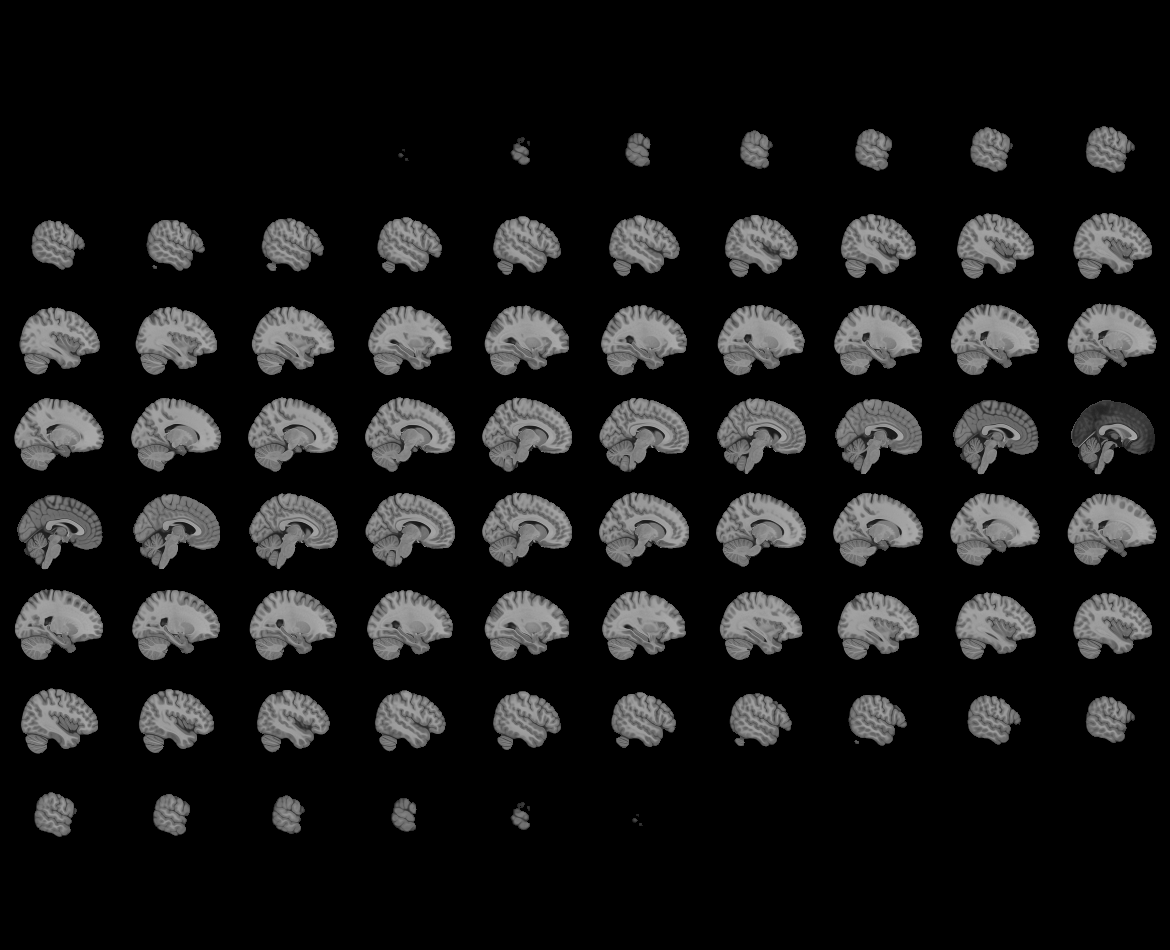
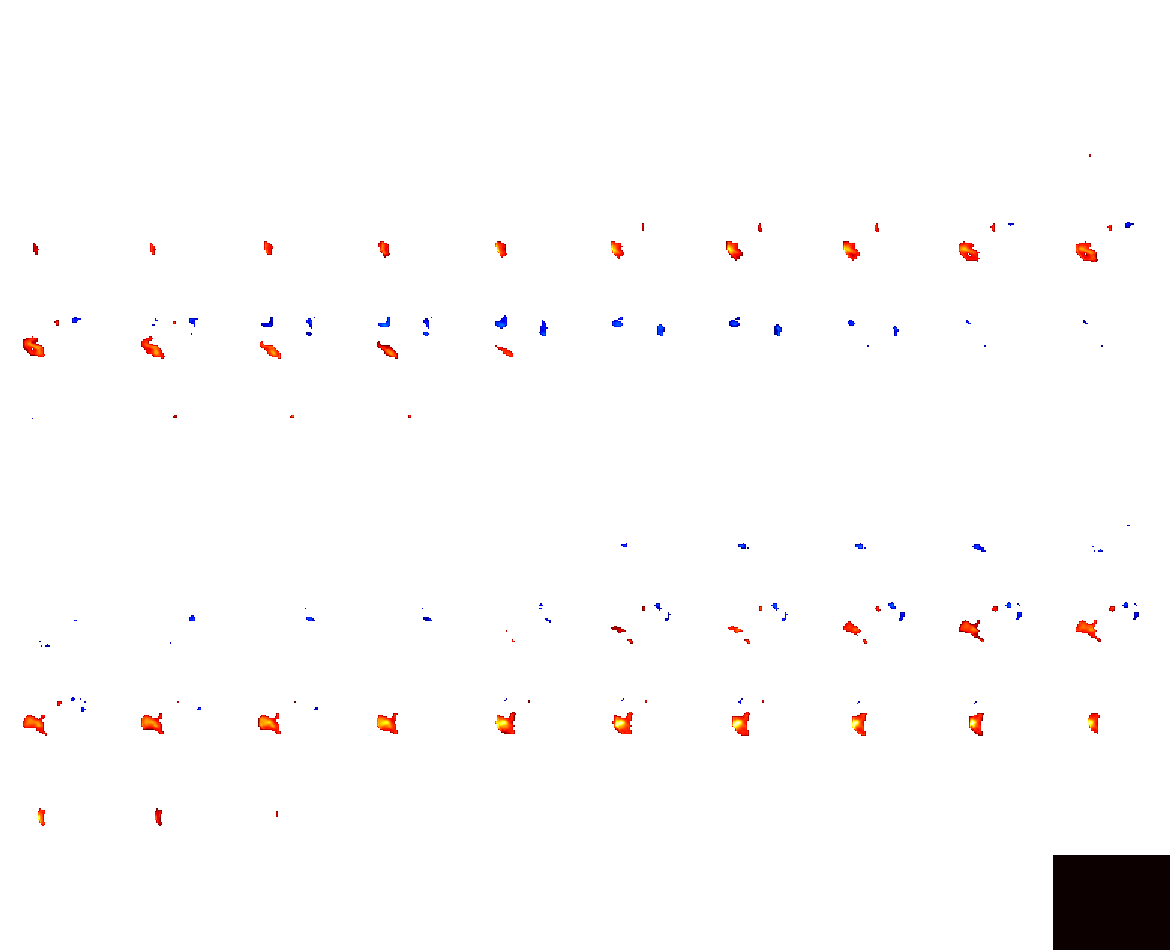

In [107]:
view_behavioral = plot_t_values_in_brain(t_values_behavioral, significant_behavioral, 'Behavioral T-values', tmp_img)
view_behavioral

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_stat_map.py:198: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(stat_map_img, ensure_finite=True)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



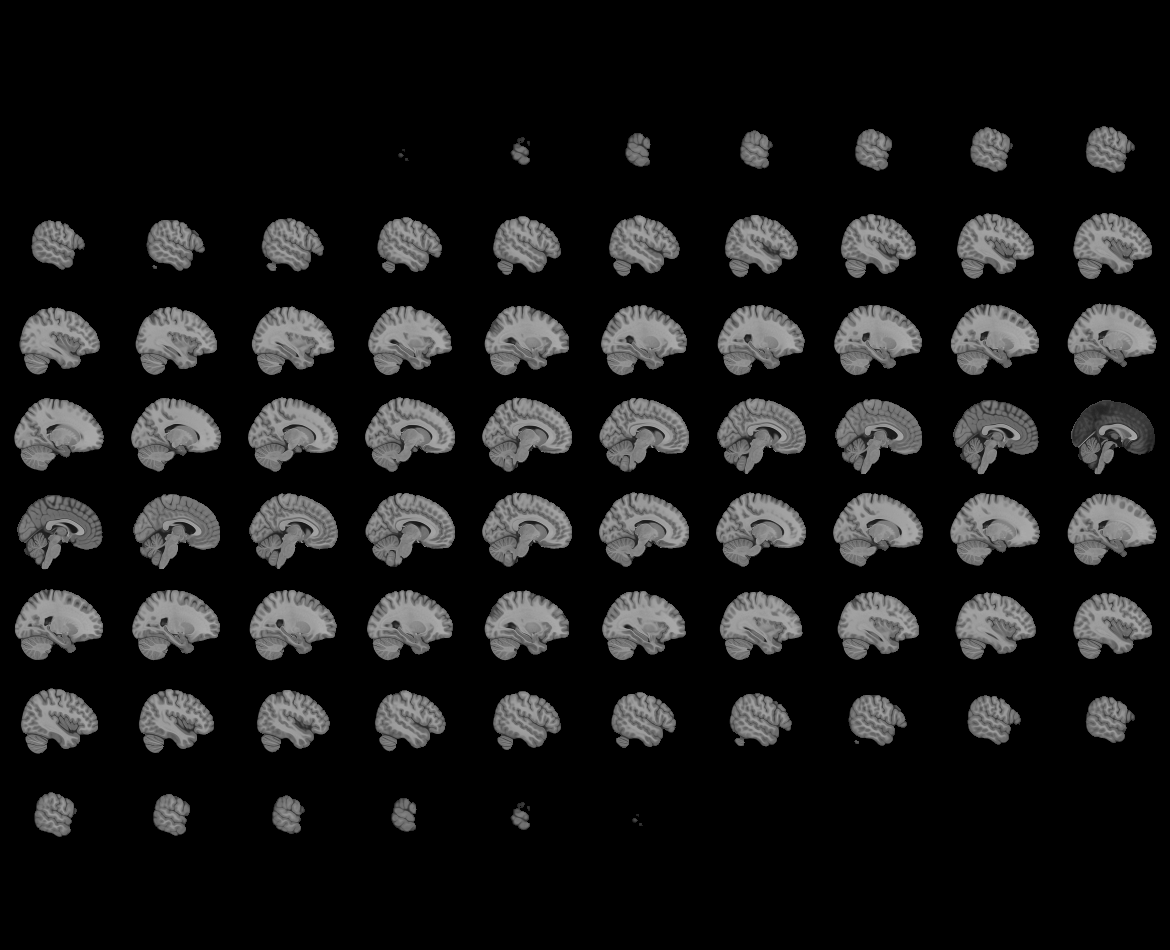
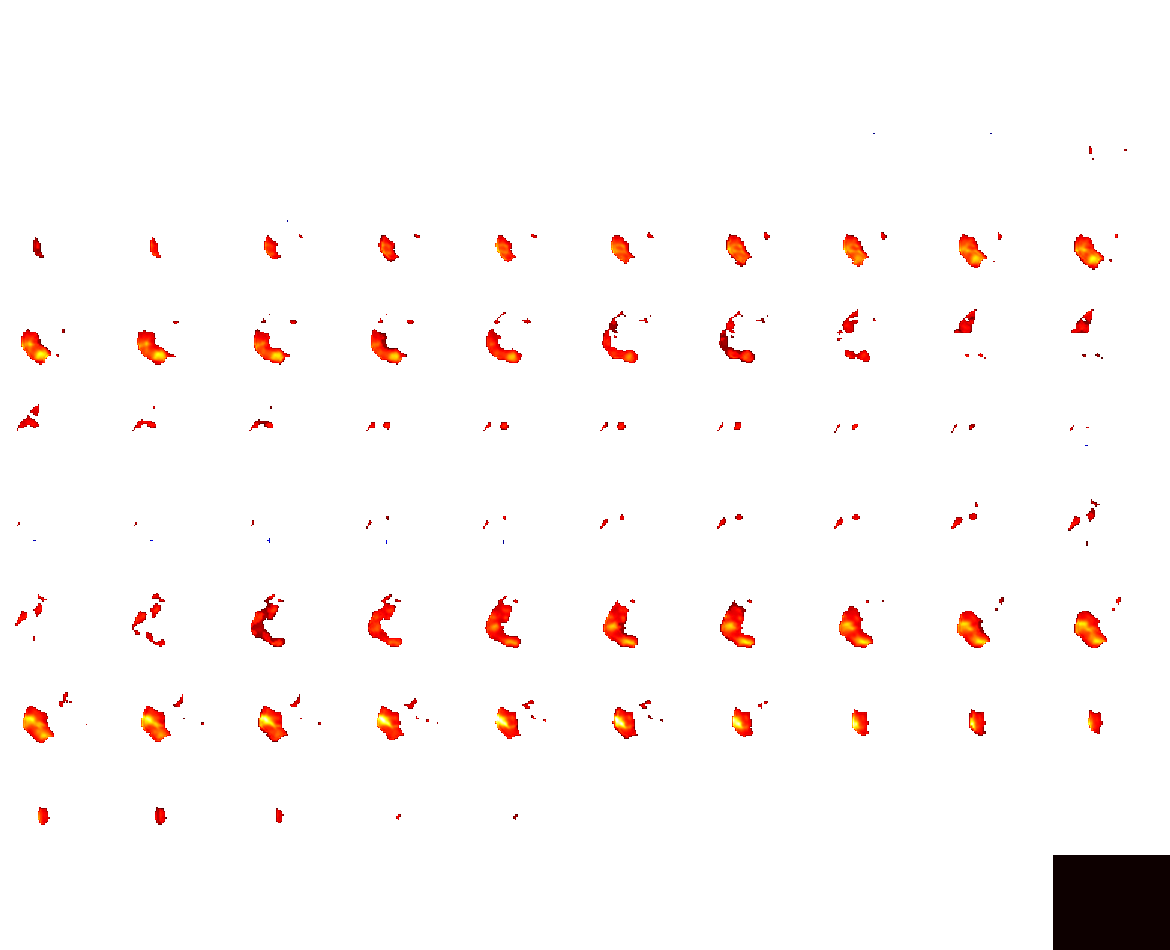

In [108]:
view_face = plot_t_values_in_brain(t_values_face, significant_face, 'Face T-values', tmp_img)
view_face

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_stat_map.py:198: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(stat_map_img, ensure_finite=True)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



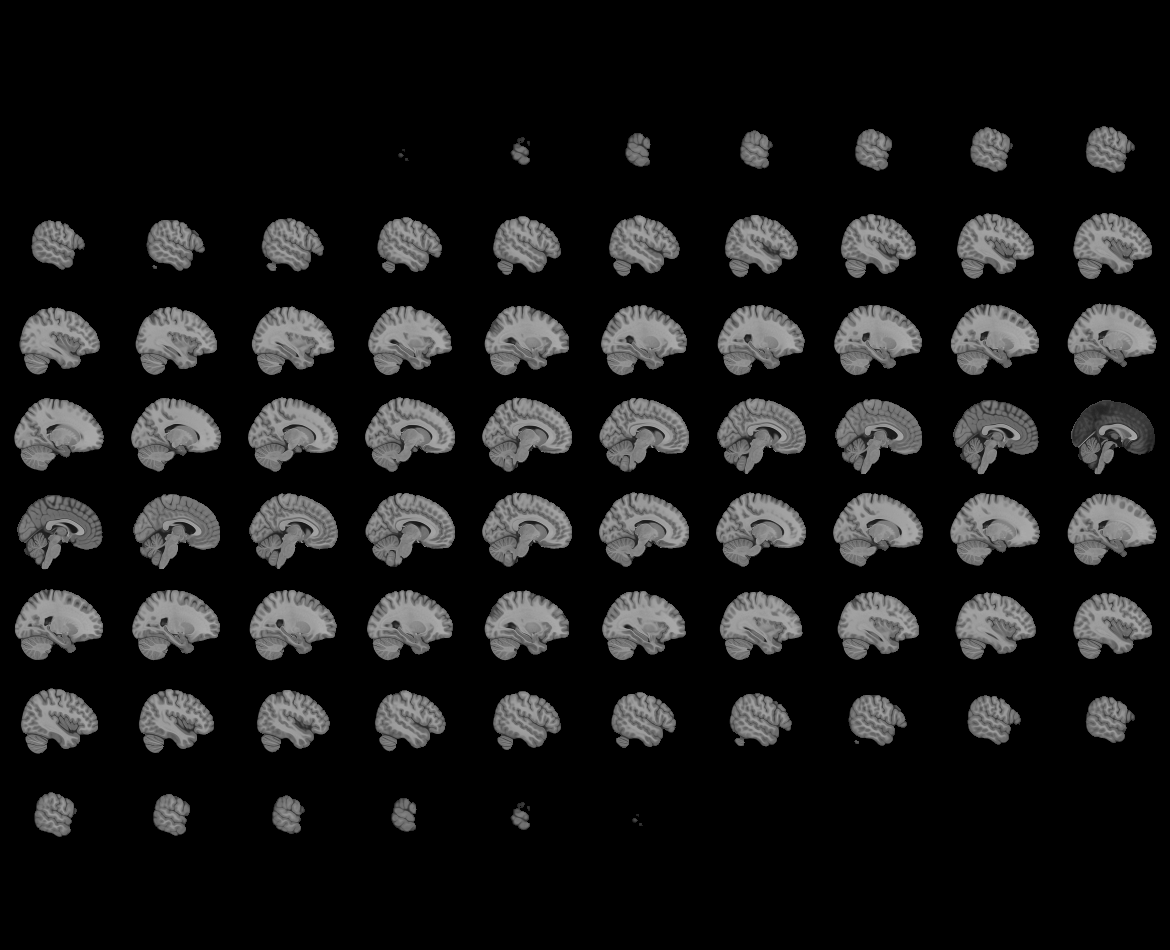
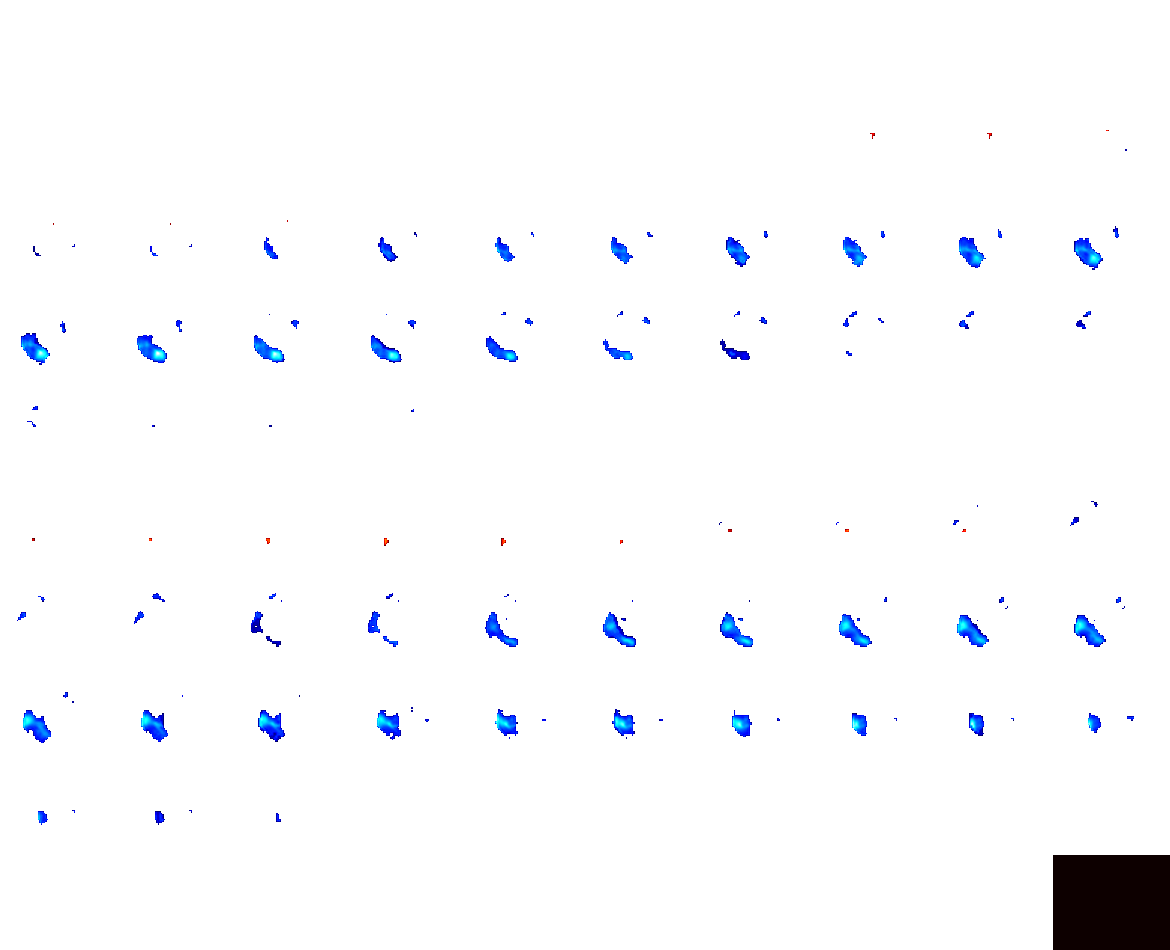

In [109]:
view_interaction = plot_t_values_in_brain(t_values_interaction, significant_interaction, 'Interaction T-values', tmp_img)
view_interaction


### Effect of radius

In [170]:
# Define the range of radius values
radius_values = range(4, 11)



# Define the searchlight_analysis function
def searchlight_analysis(allsub_avg, centers, neighbors, rdm_behavioral):
    n_subjects = allsub_avg.shape[0]
    eval_score_list = []
    
    # Flatten the behavioral RDM
    rdm_behavioral_flat = upper_triangular_flatten(rdm_behavioral)
    
    for i in range(n_subjects):
        subj_data = allsub_avg[i]  # Get data for subject i
        
        # Generate searchlight RDMs for this subject
        subj_data_2d = np.nan_to_num(subj_data)

        image_value = np.arange(60)
        SL_RDMs = get_searchlight_RDMs(subj_data_2d, centers, neighbors, image_value, method='correlation')

        # The RDMs object contains several RDM matrices, let's extract them
        for idx, rdm in enumerate(SL_RDMs):
            # Extract the RDM corresponding to the voxel center at index 'idx'
            neural_rdm_flat = rdm.dissimilarities.flatten()  # Use the flattened dissimilarities
            
            # Fit GLM to the neural RDM at this center
            betas = fit_glm_to_rdm(neural_rdm_flat, rdm_behavioral_flat)
            
            # Store the results (can be further processed or averaged over subjects)
            eval_score_list.append((centers[idx], betas))
    
    return eval_score_list

# Define the fit_glm_to_rdm function
def fit_glm_to_rdm(neural_rdm_flat, rdm_behavioral_flat):
    # Use the flattened RDMs directly
    y = neural_rdm_flat  # Neural RDM is already flattened
    X = rdm_behavioral_flat.reshape(-1, 1)  # Behavioral RDM is already flattened and reshaped for sklearn
    
    # Fit the GLM model using linear regression
    glm = LinearRegression().fit(X, y)
    
    # Return the regression coefficients (betas)
    return glm.coef_

# Define the upper_triangular_flatten function
def upper_triangular_flatten(rdm):
    """Flatten the upper triangular part of an RDM."""
    m = rdm.shape[0]
    r, c = np.triu_indices(m, 1)
    return rdm[r, c]



# Loop over each radius value
for radius in tqdm(radius_values):
    print(f"Processing radius: {radius}")
    
    # Get searchlight centers and neighbors for the current radius
    centers, neighbors = get_volume_searchlight(mask, radius=radius, threshold=0.5)
    
    # Perform searchlight analysis
    eval_score_list = searchlight_analysis(allsub_avg, centers, neighbors, rdm_behavioral)
    
    # Save the results to a pickle file
    file_path = f'./eval_score_list_radius_{radius}.pkl'
    with open(file_path, 'wb') as file:
        pickle.dump(eval_score_list, file)
    
    print(f"Results saved for radius {radius} to {file_path}")

  0%|          | 0/7 [00:00<?, ?it/s]

Processing radius: 4


Finding searchlights...: 100%|██████████| 59159/59159 [00:16<00:00, 3508.07it/s]


Found 57550 searchlights


 14%|█▍        | 1/7 [1:34:09<9:24:54, 5649.10s/it]

Results saved for radius 4 to ./eval_score_list_radius_4.pkl
Processing radius: 5


Finding searchlights...: 100%|██████████| 59159/59159 [00:22<00:00, 2656.24it/s]


Found 56949 searchlights


 29%|██▊       | 2/7 [3:23:39<8:35:56, 6191.26s/it]

Results saved for radius 5 to ./eval_score_list_radius_5.pkl
Processing radius: 6


Finding searchlights...: 100%|██████████| 59159/59159 [00:33<00:00, 1747.02it/s]


Found 56251 searchlights


 43%|████▎     | 3/7 [5:42:48<7:58:25, 7176.30s/it]

Results saved for radius 6 to ./eval_score_list_radius_6.pkl
Processing radius: 7


Finding searchlights...: 100%|██████████| 59159/59159 [00:47<00:00, 1243.70it/s]


Found 55644 searchlights


 57%|█████▋    | 4/7 [9:00:11<7:30:56, 9018.69s/it]

Results saved for radius 7 to ./eval_score_list_radius_7.pkl
Processing radius: 8


Finding searchlights...: 100%|██████████| 59159/59159 [01:05<00:00, 909.94it/s] 


Found 54934 searchlights


 71%|███████▏  | 5/7 [13:24:37<6:22:55, 11487.81s/it]

Results saved for radius 8 to ./eval_score_list_radius_8.pkl
Processing radius: 9


Finding searchlights...: 100%|██████████| 59159/59159 [01:36<00:00, 612.61it/s]


Found 54259 searchlights


 86%|████████▌ | 6/7 [18:51:56<3:57:39, 14259.14s/it]

Results saved for radius 9 to ./eval_score_list_radius_9.pkl
Processing radius: 10


Finding searchlights...: 100%|██████████| 59159/59159 [3:08:22<00:00,  5.23it/s]


Found 53626 searchlights


100%|██████████| 7/7 [30:28:17<00:00, 15671.08s/it]  

Results saved for radius 10 to ./eval_score_list_radius_10.pkl


## GLM with social


In [118]:
eval_score_list = searchlight_analysis(allsub_avg, centers, neighbors, rdm_behavioral, rdm_social)



Calculating RDMs...: 100%|██████████| 100/100 [04:24<00:00,  2.64s/it]


In [119]:
# Define the file path where you want to save the pickle file
file_path = './eval_score_list_social.pkl'

# Save eval_score_list to a pickle file
with open(file_path, 'wb') as file:
    pickle.dump(eval_score_list, file)


In [127]:
n_subjects = 20
n_voxel_centers = len(eval_score_list) // n_subjects

# Extract betas for each term and reshape
betas_behavioral = np.array([betas[0] for _, betas in eval_score_list]).reshape(n_subjects, n_voxel_centers)
betas_face = np.array([betas[1] for _, betas in eval_score_list]).reshape(n_subjects, n_voxel_centers)
betas_interaction = np.array([betas[2] for _, betas in eval_score_list]).reshape(n_subjects, n_voxel_centers)
# Perform t-tests across subjects for each term
t_values_behavioral, p_values_behavioral = stats.ttest_1samp(betas_behavioral, 0, axis=0)
t_values_face, p_values_face = stats.ttest_1samp(betas_face, 0, axis=0)
t_values_interaction, p_values_interaction = stats.ttest_1samp(betas_interaction, 0, axis=0)
# Apply FDR correction
_, p_values_behavioral_fdr = fdrcorrection(p_values_behavioral, alpha=0.05)
_, p_values_face_fdr = fdrcorrection(p_values_face, alpha=0.05)
_, p_values_interaction_fdr = fdrcorrection(p_values_interaction, alpha=0.05)
# Select significant voxel centers
significant_behavioral = p_values_behavioral_fdr < 0.01
significant_face = p_values_face_fdr < 0.01
significant_interaction = p_values_interaction_fdr < 0.01

In [128]:
# Dimensions of the voxel space
x, y, z = 53, 63, 46  # Adjust these dimensions to match your data

# Extract unique voxel indices from the first subject's data
n_subjects = 20
voxel_indices = np.array([center for center, _ in eval_score_list[:len(eval_score_list) // n_subjects]])

# Function to map t-values to voxel space and plot
def plot_t_values_in_brain(t_values, significant_mask, title, tmp_img):
    # Initialize an array for the t-statistics in 3D space
    t_stat_sig = np.full((x * y * z), np.nan)
    
    # Map significant t-values to their voxel indices
    significant_voxel_indices = voxel_indices[significant_mask]
    t_stat_sig[significant_voxel_indices] = t_values[significant_mask]
    
    # Reshape the 1D t-statistics array into a 3D array matching the voxel space
    t_stat_sig_3d = t_stat_sig.reshape([x, y, z])
    
    # Create a new image object from the 3D t-statistics
    t_stat_sig_img = new_img_like(tmp_img, t_stat_sig_3d)
    
    # View the image
    view = plotting.view_img(t_stat_sig_img, title=title)
    return view

### Plotting

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_stat_map.py:198: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(stat_map_img, ensure_finite=True)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



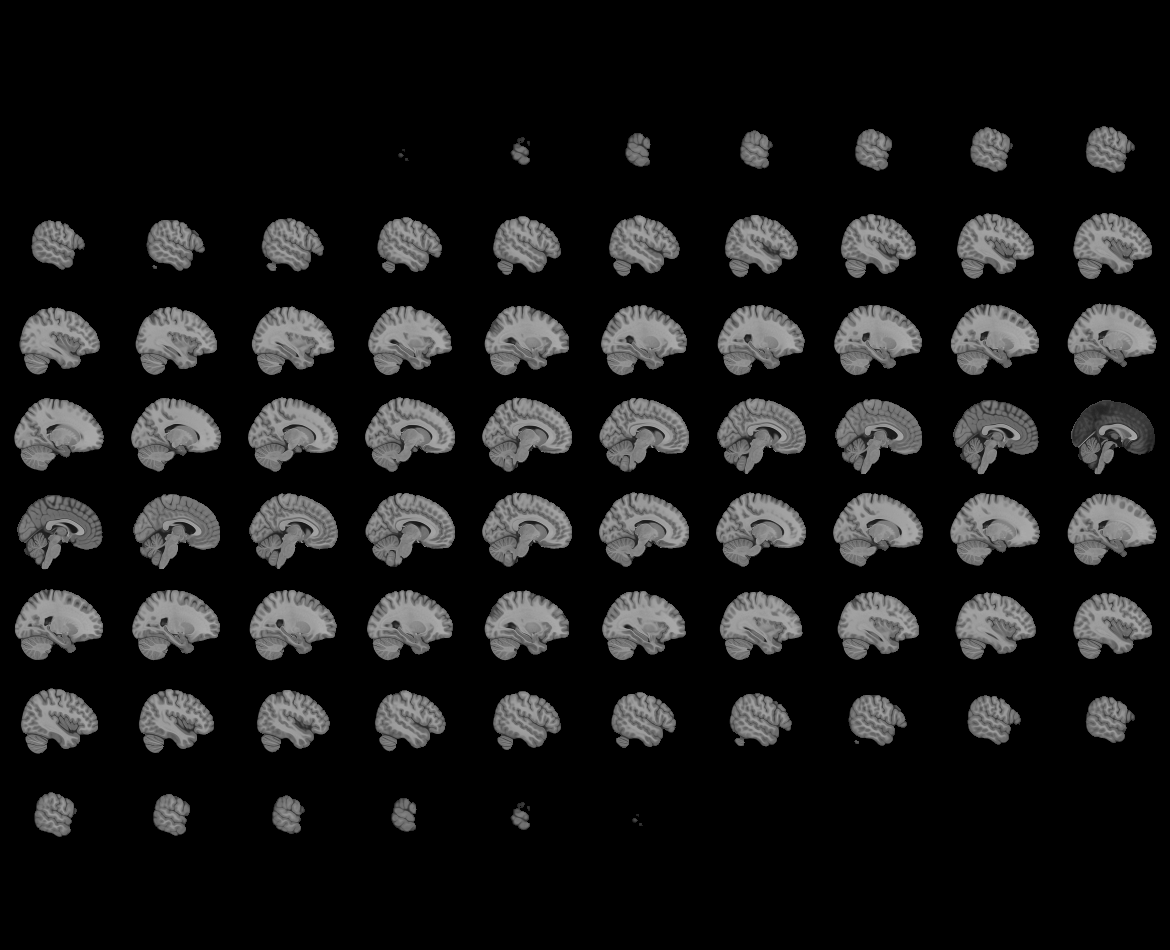
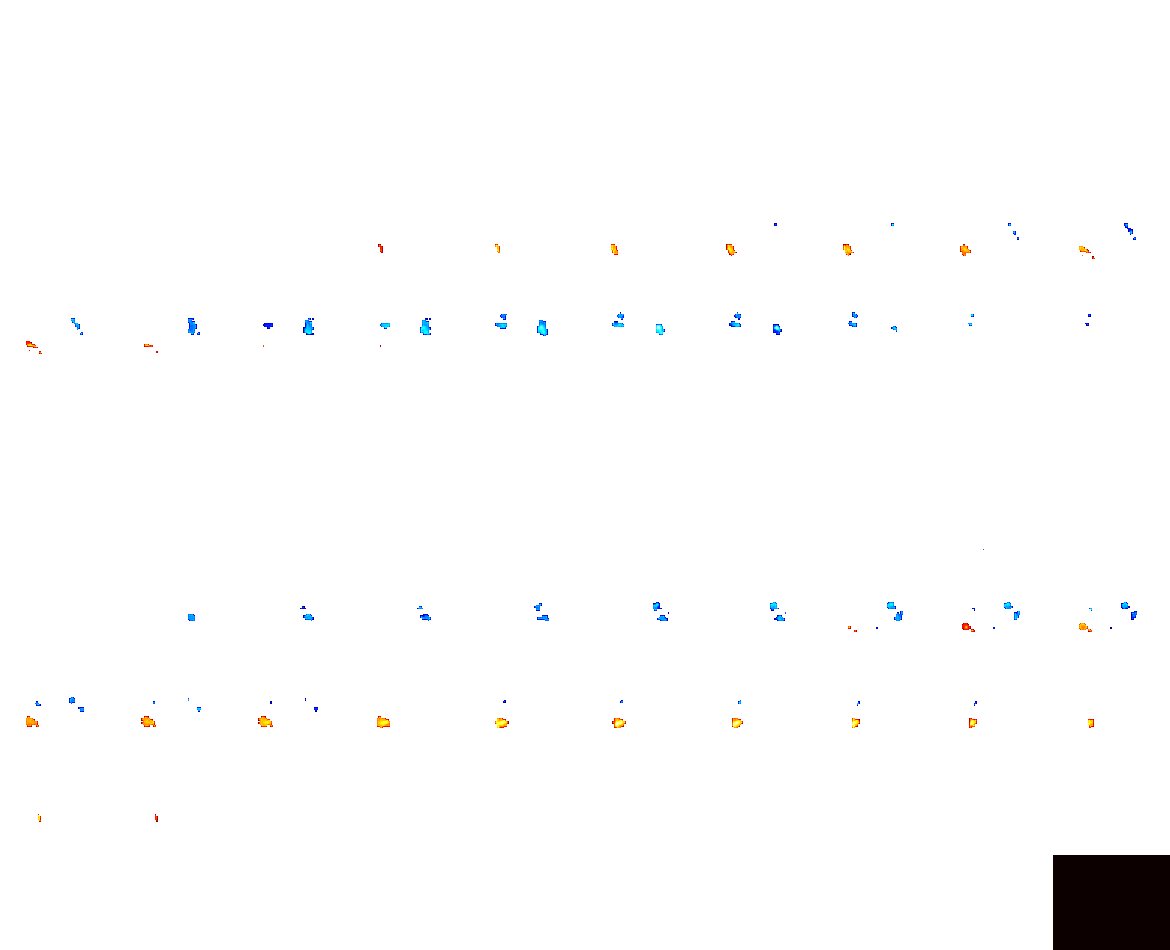

In [129]:
view_behavioral = plot_t_values_in_brain(t_values_behavioral, significant_behavioral, 'Behavioral T-values', tmp_img)
view_behavioral

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_stat_map.py:198: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(stat_map_img, ensure_finite=True)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



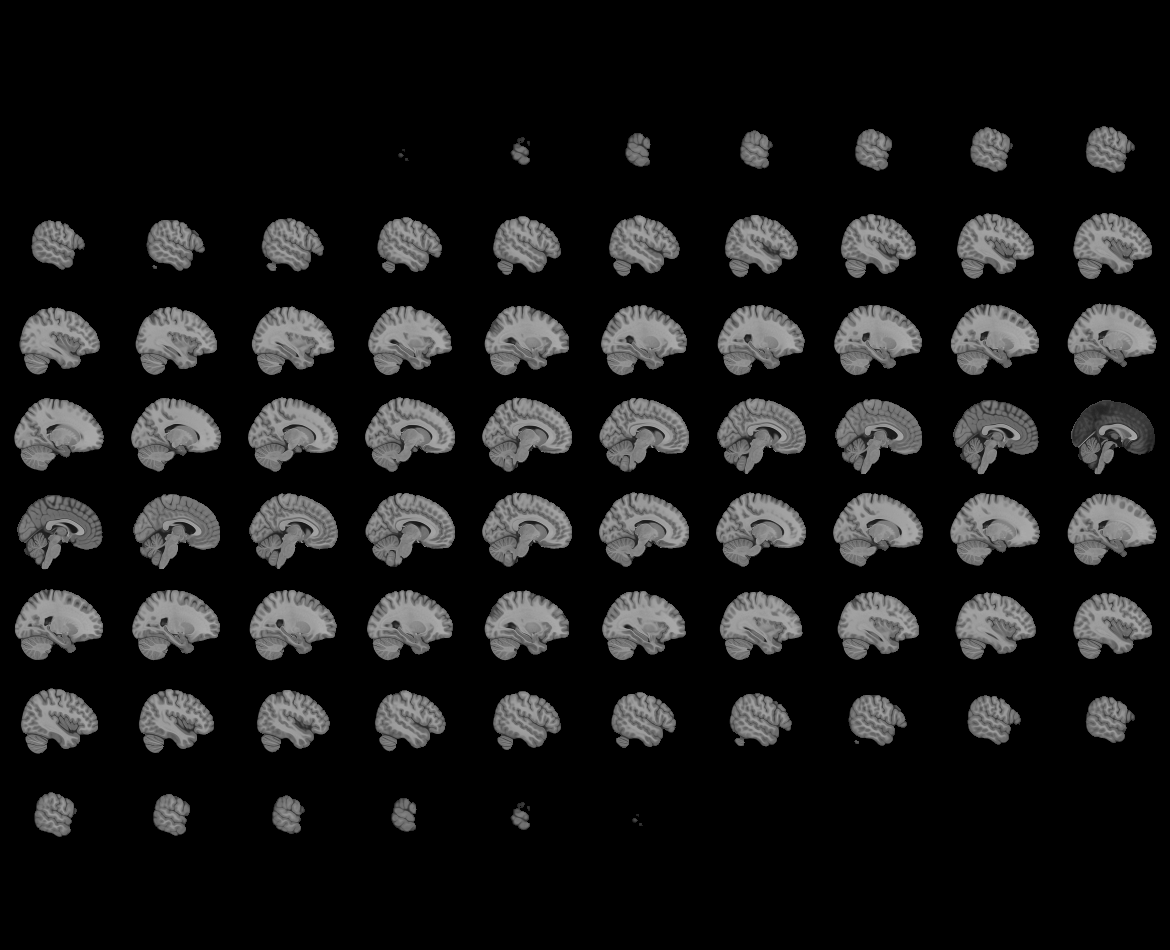
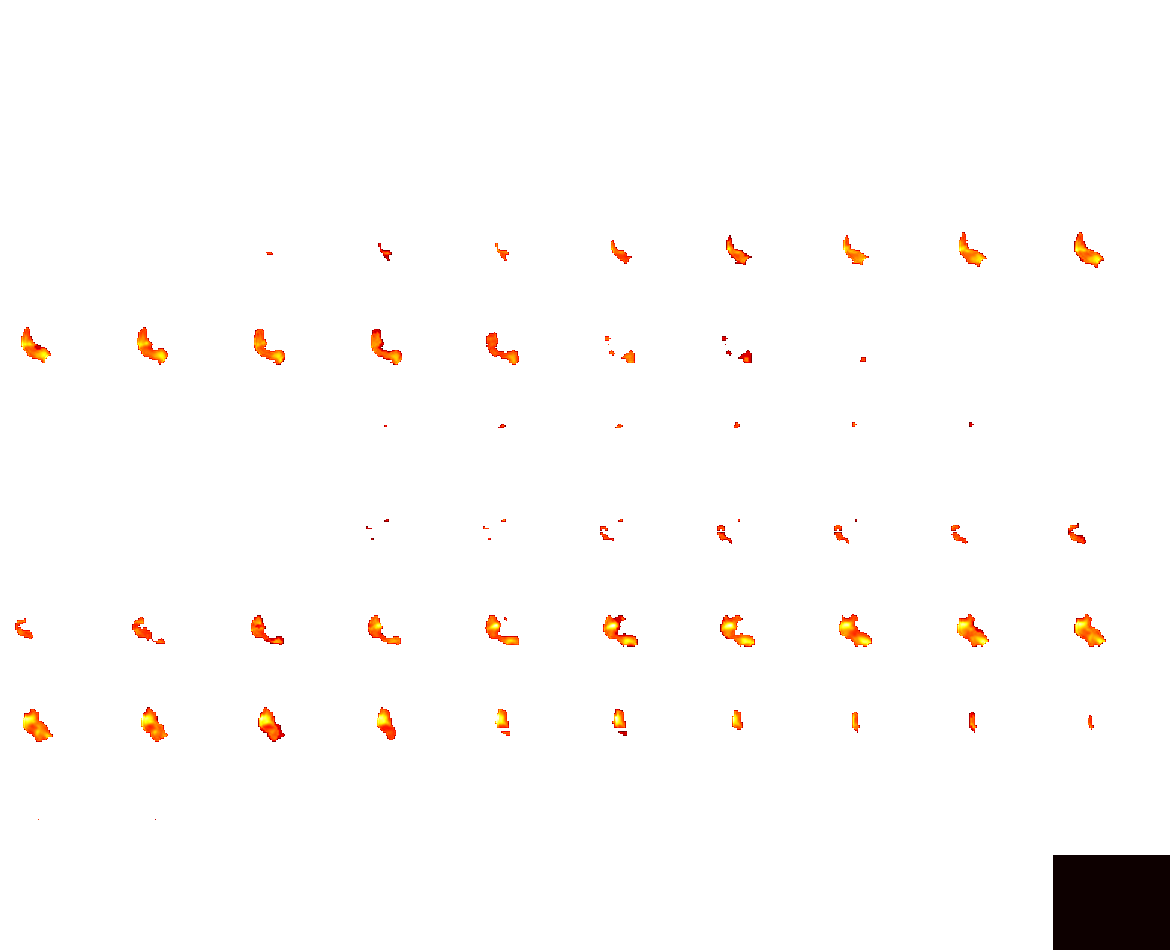

In [130]:
view_social = plot_t_values_in_brain(t_values_face, significant_face, 'Social T-values', tmp_img)
view_social

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_stat_map.py:198: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(stat_map_img, ensure_finite=True)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_document.py:102: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(



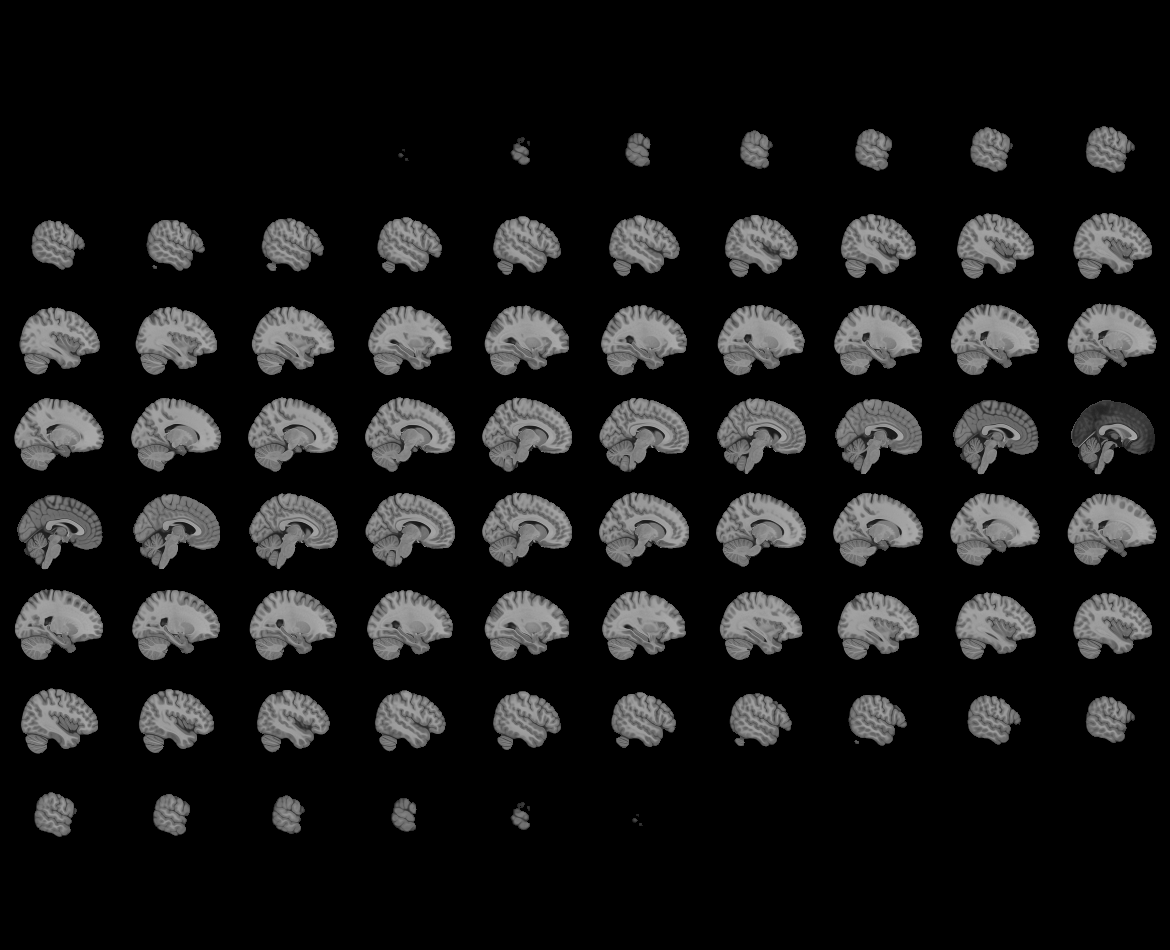
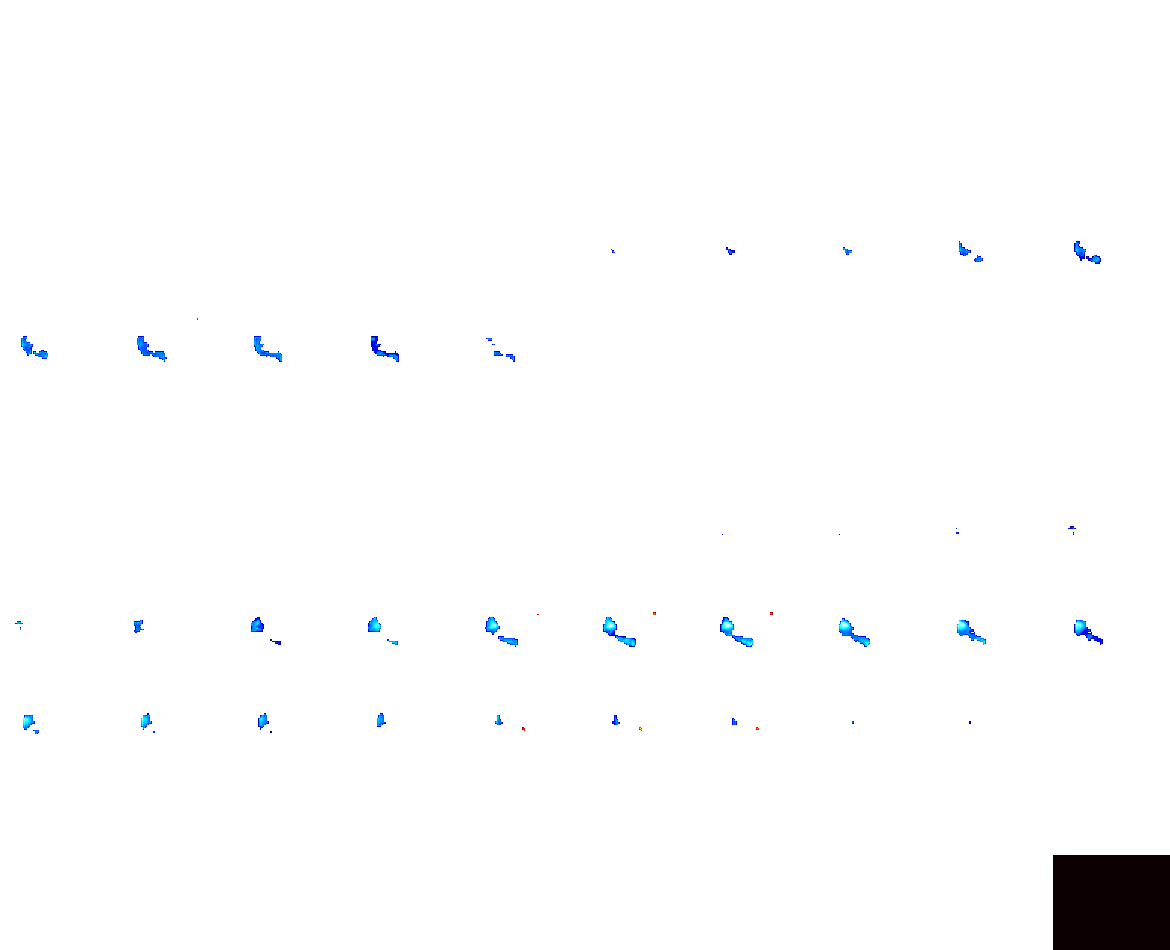

In [131]:
view_interaction = plot_t_values_in_brain(t_values_interaction, significant_interaction, 'Interaction (Behavioral x Social) T-values', tmp_img)
view_interaction

## GLM with CLIP text embeddings


In [134]:
# Define the file path to the pickle file
file_path = './clip_text_embeddigs.pkl'

# Load the pickle file
with open(file_path, 'rb') as file:
    clip_text_embeddings = pickle.load(file)


In [135]:
rdm_clip_text = 1 - np.corrcoef(clip_text_embeddings)

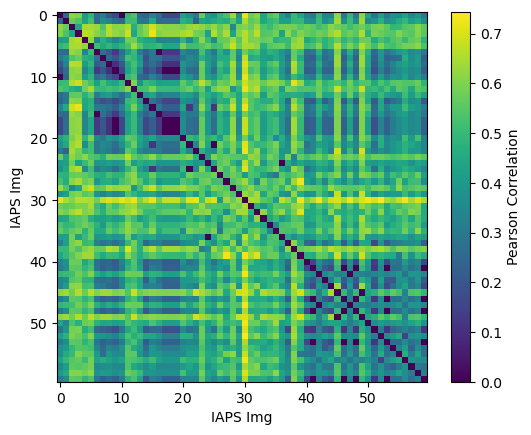

In [169]:

# make plot
fig, ax = plt.subplots(facecolor='white')
  
# show image
shw = ax.imshow(rdm_clip_text)
  
# make bar
bar = plt.colorbar(shw)
  
# show plot with labels
plt.xlabel('IAPS Img')
plt.ylabel('IAPS Img')
# plt.xticks(ticks=np.arange(len(stim_with_flags['iaps_id'])), labels=stim_with_flags['iaps_id'])
# plt.yticks(ticks=np.arange(len(stim_with_flags['iaps_id'])), labels=stim_with_flags['iaps_id'])

bar.set_label('Pearson Correlation')
plt.show()

In [138]:
eval_score_list = searchlight_analysis(allsub_avg, centers, neighbors, rdm_behavioral, rdm_clip_text)

Calculating RDMs...: 100%|██████████| 100/100 [04:35<00:00,  2.76s/it]


### Export results

In [139]:
# Define the file path where you want to save the pickle file
file_path = './eval_score_list_textembed.pkl'

# Save eval_score_list to a pickle file
with open(file_path, 'wb') as file:
    pickle.dump(eval_score_list, file)

In [142]:
n_subjects = 20
n_voxel_centers = len(eval_score_list) // n_subjects

# Extract betas for each term and reshape
betas_behavioral = np.array([betas[0] for _, betas in eval_score_list]).reshape(n_subjects, n_voxel_centers)
betas_textembed = np.array([betas[1] for _, betas in eval_score_list]).reshape(n_subjects, n_voxel_centers)
betas_interaction = np.array([betas[2] for _, betas in eval_score_list]).reshape(n_subjects, n_voxel_centers)
# Perform t-tests across subjects for each term
t_values_behavioral, p_values_behavioral = stats.ttest_1samp(betas_behavioral, 0, axis=0)
t_values_textembed, p_values_textembed = stats.ttest_1samp(betas_textembed, 0, axis=0)
t_values_interaction, p_values_interaction = stats.ttest_1samp(betas_interaction, 0, axis=0)
# Apply FDR correction
_, p_values_behavioral_fdr = fdrcorrection(p_values_behavioral, alpha=0.05)
_, p_values_textembed_fdr = fdrcorrection(p_values_textembed, alpha=0.05)
_, p_values_interaction_fdr = fdrcorrection(p_values_interaction, alpha=0.05)
# Select significant voxel centers
significant_behavioral = p_values_behavioral_fdr < 0.05
significant_textembed = p_values_textembed_fdr < 0.05
significant_interaction = p_values_interaction_fdr < 0.05


In [143]:
# Dimensions of the voxel space
x, y, z = 53, 63, 46  # Adjust these dimensions to match your data

# Extract unique voxel indices from the first subject's data
n_subjects = 20
voxel_indices = np.array([center for center, _ in eval_score_list[:len(eval_score_list) // n_subjects]])

# Function to map t-values to voxel space and plot
def plot_t_values_in_brain(t_values, significant_mask, title, tmp_img):
    # Initialize an array for the t-statistics in 3D space
    t_stat_sig = np.full((x * y * z), np.nan)
    
    # Map significant t-values to their voxel indices
    significant_voxel_indices = voxel_indices[significant_mask]
    t_stat_sig[significant_voxel_indices] = t_values[significant_mask]
    
    # Reshape the 1D t-statistics array into a 3D array matching the voxel space
    t_stat_sig_3d = t_stat_sig.reshape([x, y, z])
    
    # Create a new image object from the 3D t-statistics
    t_stat_sig_img = new_img_like(tmp_img, t_stat_sig_3d)
    
    # View the image
    view = plotting.view_img(t_stat_sig_img, title=title)
    return view

### Plotting


c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_stat_map.py:198: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(stat_map_img, ensure_finite=True)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_document.py:102: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(



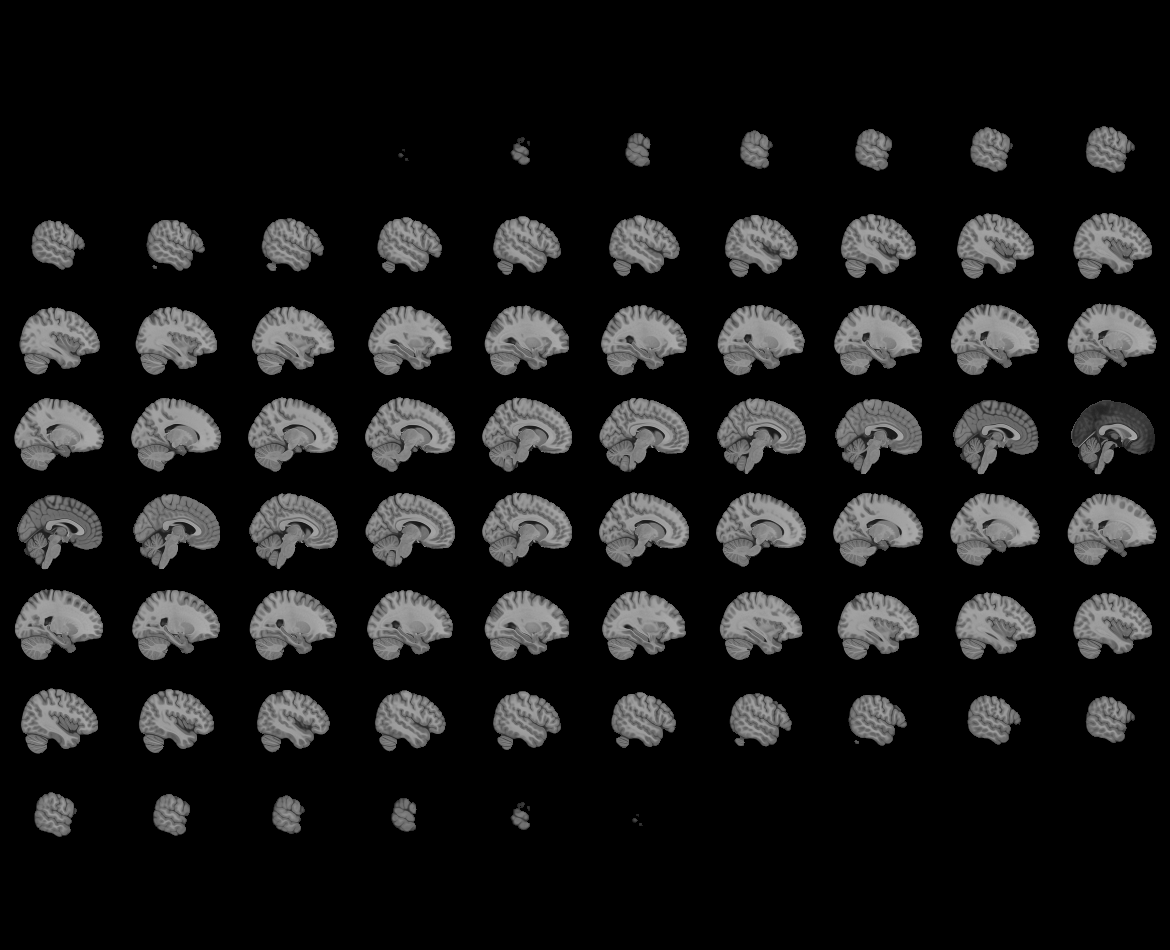
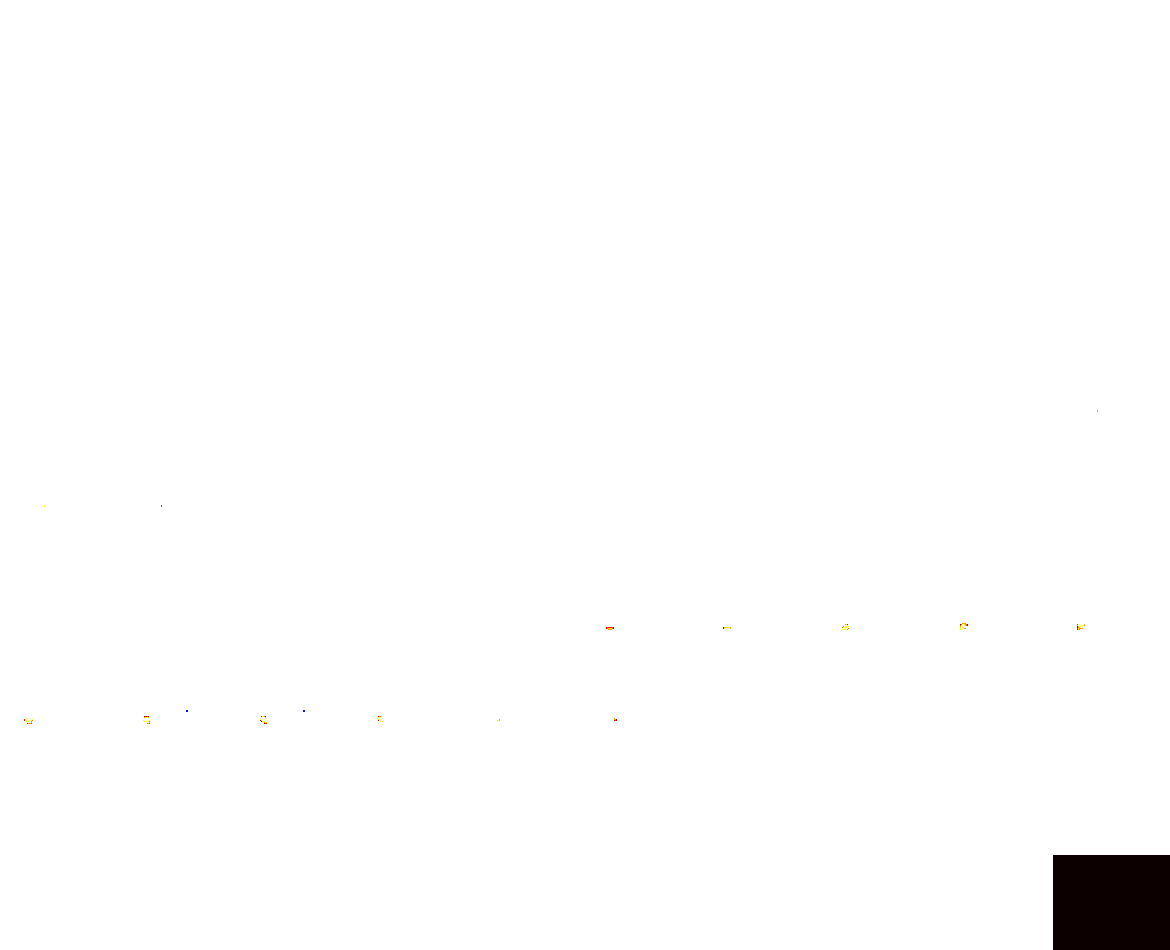

In [144]:
view_behavioral = plot_t_values_in_brain(t_values_behavioral, significant_behavioral, 'Behavioral T-values', tmp_img)
view_behavioral




c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_stat_map.py:198: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(stat_map_img, ensure_finite=True)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_document.py:102: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(



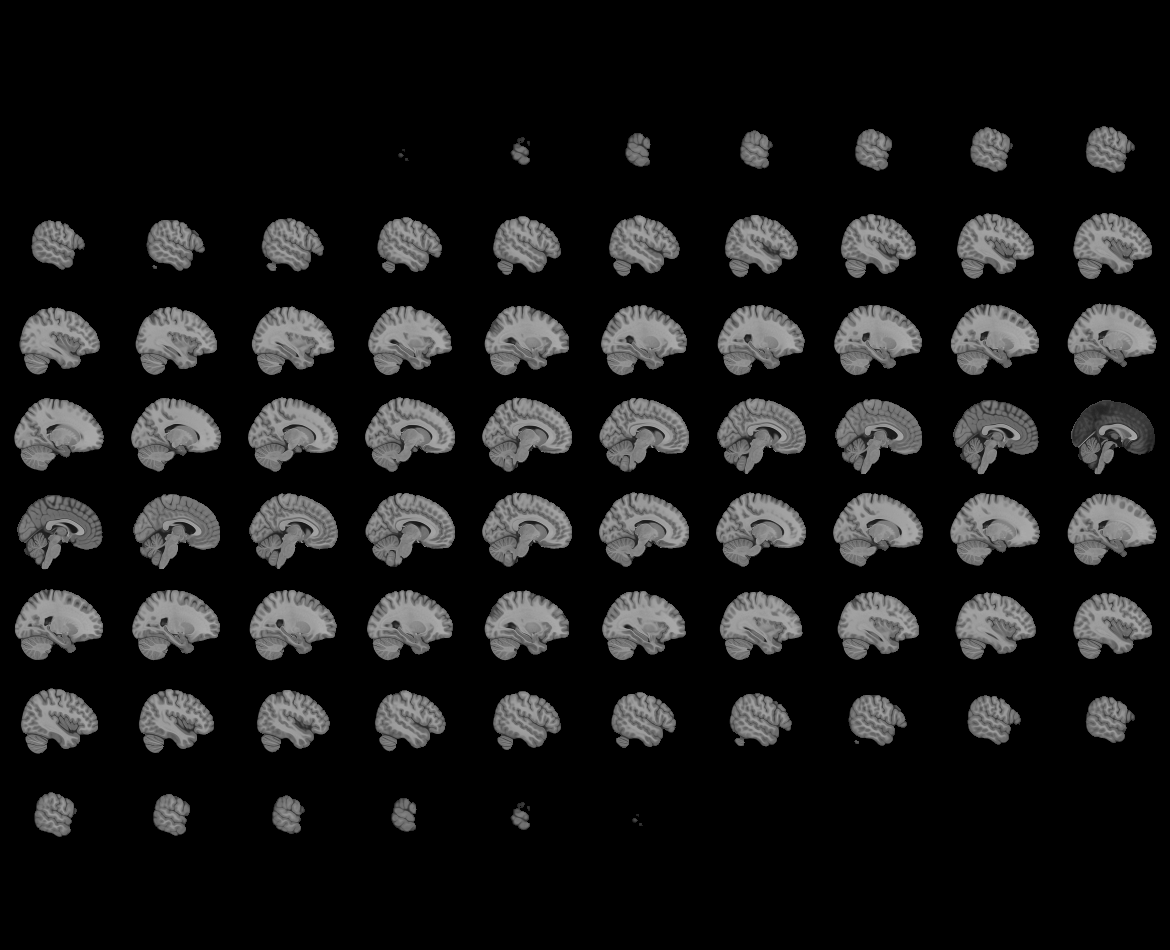
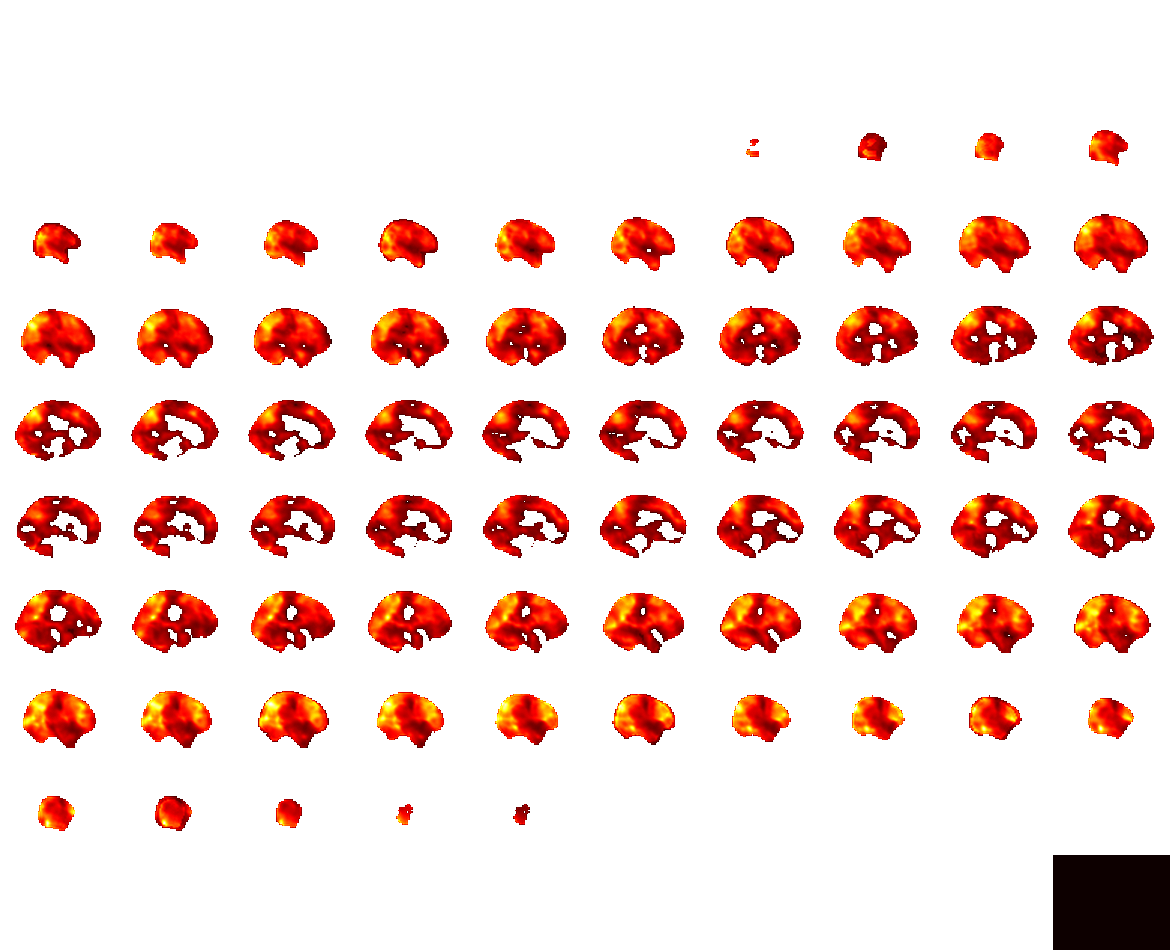

In [145]:
view_textembed = plot_t_values_in_brain(t_values_textembed, significant_textembed, 'Text Embedding T-values', tmp_img)
view_textembed


c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_stat_map.py:198: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(stat_map_img, ensure_finite=True)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\plotting\html_document.py:102: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(



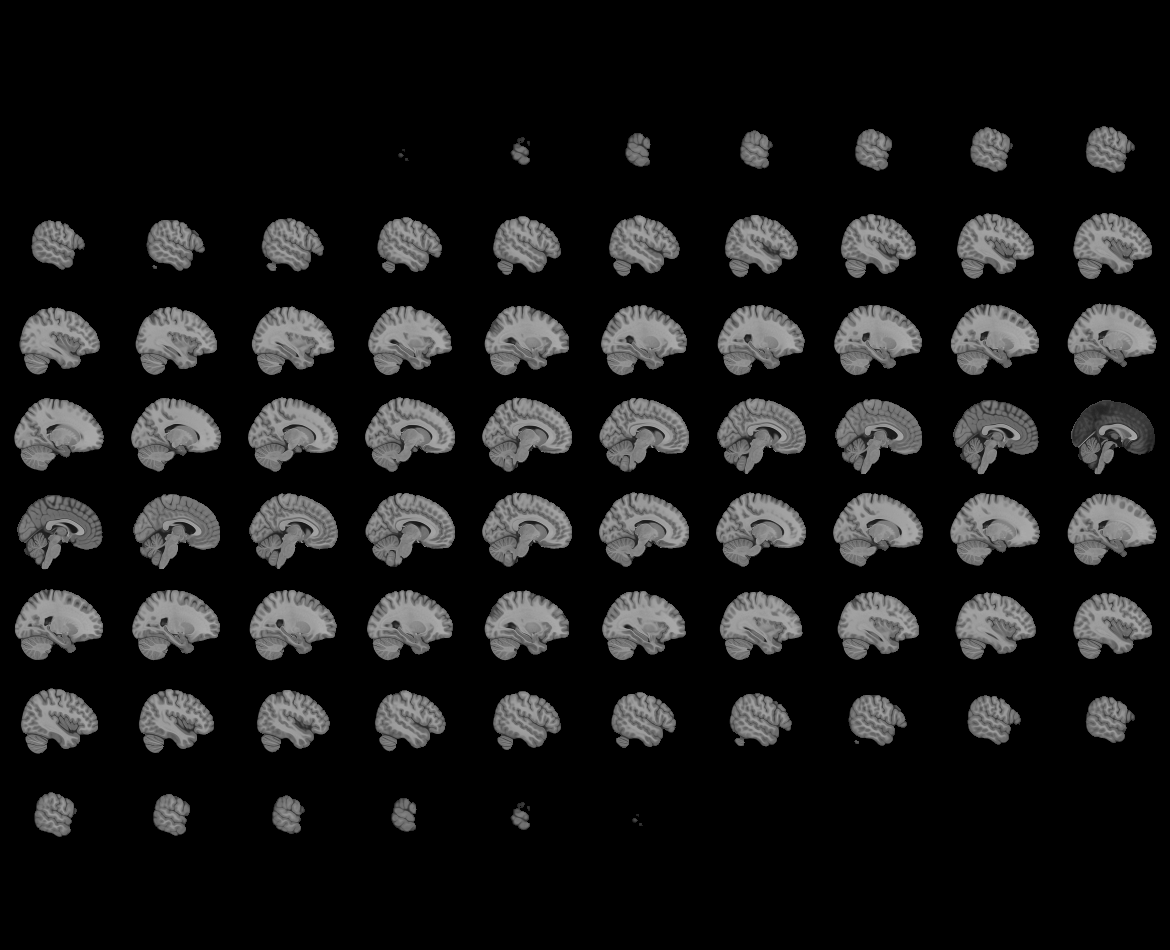
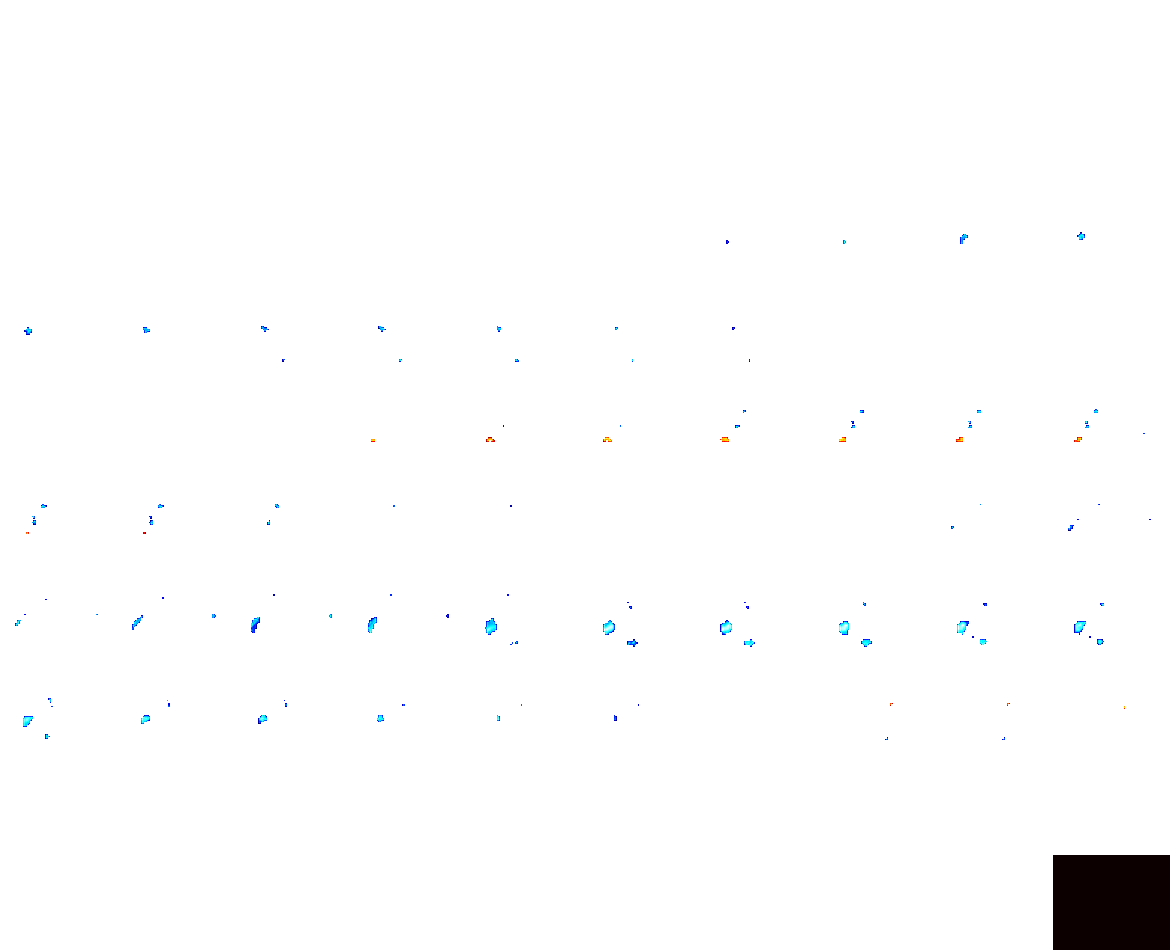

In [146]:
view_interaction = plot_t_values_in_brain(t_values_interaction, significant_interaction, 'Interaction (Behavioral x Text Embedding) T-values', tmp_img)
view_interaction